"""
Name: Module 6 Academic Success.py
Assignment 3 and 4 - logit regression
"""

In [1]:
# 
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn
import matplotlib.pyplot as plt
import numpy
import pandas
import sys
from scipy.stats import chi2
import os

# Find CSP571 folder by walking up from cwd
cwd = os.path.abspath(os.getcwd())
search_dir = cwd
base_dir = None
for _ in range(5):
    candidate = os.path.join(search_dir, "CSP571")
    if os.path.isdir(candidate) and os.path.isfile(os.path.join(candidate, "raw", "Utility.py")):
        base_dir = candidate
        break
    search_dir = os.path.dirname(search_dir)

if base_dir is None:
    raise FileNotFoundError("Could not locate CSP571/raw/Utility.py from current working directory.")

sys.path.append(os.path.join(base_dir, "raw")) 
import Utility

# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)
pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)
pandas.options.display.float_format = '{:,.10f}'.format



TransportMode: mode of transportation, 
a categorical predictor that has four levels: Bike, Drive, Public, and Walk

CommuteMile: number of miles for commuting, an interval predictor

Late4Work: late for work indicator, a binary target that has two levels: No and Yes

We ask you to train a binary logistic regression model that includes the Intercept term, TransportMode, and CommuteMile. Based on the model results, what phenomenon can you conclude the model is having?

In [2]:
q5 = pandas.read_csv(r'data\FinalQ5.csv')
# q5.isnull().sum()

# convert resposne to binary numerical variable 
q5['Late4Work'] = q5['Late4Work'].map({'Yes': 1, 'No': 0})
q5.groupby('Late4Work').count()  

# X = q5[['CommuteMile', 'Late4Work']].copy()
# y = q5['Late4Work'].copy()
q5.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TransportMode  500 non-null    object
 1   CommuteMile    500 non-null    int64 
 2   Late4Work      500 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 11.8+ KB


In [7]:
# Binary logit: Late4Work ~ Intercept + TransportMode + CommuteMile
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationError

model_df = q5.copy()

# One-hot encode the categorical predictor with "Bike" as the baseline.
X = pandas.get_dummies(
    model_df[["TransportMode", "CommuteMile"]],
    columns=["TransportMode"],
    drop_first=True,
    dtype=float,
 )
X = sm.add_constant(X, has_constant="add")
y = model_df["Late4Work"].astype(int)

print("Design matrix columns:", list(X.columns))
print("Target counts:\n", y.value_counts().sort_index())

try:
    logit_model = sm.Logit(y, X)
    logit_result = logit_model.fit(disp=False, maxiter=200)
    print(logit_result.summary())

    # Convert coefficients to odds ratios for easier interpretation.
    odds_ratios = pandas.Series(
        numpy.exp(logit_result.params),
        index=logit_result.params.index,
        name="odds_ratio",
    )
    print("\nOdds ratios:\n", odds_ratios)
except PerfectSeparationError as err:
    print("Perfect separation detected. The MLE does not exist for this model.")
    print(err)

Design matrix columns: ['const', 'CommuteMile', 'TransportMode_Drive', 'TransportMode_Public', 'TransportMode_Walk']
Target counts:
 Late4Work
0    397
1    103
Name: count, dtype: int64
                           Logit Regression Results                           
Dep. Variable:              Late4Work   No. Observations:                  500
Model:                          Logit   Df Residuals:                      495
Method:                           MLE   Df Model:                            4
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                 0.01027
Time:                        15:53:49   Log-Likelihood:                -251.69
converged:                      False   LL-Null:                       -254.30
Covariance Type:            nonrobust   LLR p-value:                    0.2651
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
con

c:\Users\abhis\git\mas\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [8]:
# Check class balance by TransportMode to diagnose separation.
pandas.crosstab(q5['TransportMode'], q5['Late4Work'])

Late4Work,0,1
TransportMode,,
Bike,43,15
Drive,193,58
Public,160,30
Walk,1,0


In [12]:
# p values of all variables
print ("\nP-values:\n", logit_result.pvalues)

# p signifnact values
significant_vars = logit_result.pvalues[logit_result.pvalues < 0.05].index.tolist()
print("\nSignificant variables at alpha=0.05:\n", significant_vars)


P-values:
 const                  0.0029804184
CommuteMile            0.8606840292
TransportMode_Drive    0.6541583521
TransportMode_Public   0.0844680832
TransportMode_Walk     0.9996575667
dtype: float64

Significant variables at alpha=0.05:
 ['const']


In [14]:
# Check outcome distribution for each (TransportMode, CommuteMile) combination.
combo_counts = (
    q5.groupby(['TransportMode', 'CommuteMile'])['Late4Work']
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={0: 'No(0)', 1: 'Yes(1)'})
)

one_class_combos = combo_counts[(combo_counts['No(0)'] == 0) | (combo_counts['Yes(1)'] == 0)]
print('Total unique combinations:', len(combo_counts))
print('One-class-only combinations:', len(one_class_combos))
print(one_class_combos.head(20))

Total unique combinations: 20
One-class-only combinations: 2
Late4Work                  No(0)  Yes(1)
TransportMode CommuteMile               
Bike          0                6       0
Walk          0                1       0


In [4]:
import numpy as np
from scipy.stats import chi2_contingency

# Define the contingency table based on the image
# Rows: Vehicle Age (1 to 3, 4 to 7, 8 to 10, 11+)
# Columns: Claim Indicator (No, Yes)
observed_data = np.array([
    [1731, 846],
    [1246, 490],
    [1412, 543],
    [2700, 690]
])

# 1. Calculate the Chi-Square statistic
# chi2_contingency returns the test statistic, p-value, degrees of freedom, and expected frequencies
chi2_stat, p_val, dof, expected_freq = chi2_contingency(observed_data)

# 2. Calculate Cramer's V
# Get the grand total (N)
n = observed_data.sum()

# Get the minimum of (rows - 1) and (columns - 1)
min_dim = min(observed_data.shape[0] - 1, observed_data.shape[1] - 1)

# Apply Cramer's V formula
cramers_v = np.sqrt(chi2_stat / (n * min_dim))

# 3. Output the results
print("--- Statistical Results ---")
print(f"Total Observations (N): {n}")
print(f"Chi-Square Statistic:   {chi2_stat:.2f}")
print(f"P-value:                {p_val:.2e}")
print(f"Degrees of Freedom:     {dof}")
print(f"Cramer's V:             {cramers_v:.4f}")

# (Optional) If you have a newer version of SciPy (1.7.0+), 
# you can also use the built-in association function:
# from scipy.stats.contingency import association
# print(f"Cramer's V (built-in):  {association(observed_data, method='cramer'):.3f}")

--- Statistical Results ---
Total Observations (N): 9658
Chi-Square Statistic:   122.68
P-value:                2.04e-26
Degrees of Freedom:     3
Cramer's V:             0.1127


In [5]:
# read FinalQ12.csv
q12 = pandas.read_csv(r'data\FinalQ12.csv')
q12




,z
0,-6.5620000000
1,-9.8870000000
2,5.8040000000
3,-1.8160000000
4,-2.3080000000
...,...
495,2.2380000000
496,8.4510000000
497,0.4920000000
498,-6.9810000000


### K-Means Clustering Analysis on 'z' Feature

The data has 500 observations with one feature (z). We'll use k-Means with Euclidean distance to discover clusters for k=2 to k=10.

In [6]:
# Import necessary libraries for clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for clustering
X_cluster = q12[['z']].values

# Test k from 2 to 10
k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("K-Means Clustering Results:")
print("="*60)
print(f"{'k':<5} {'Inertia':<20} {'Silhouette Score':<20}")
print("="*60)

for k in k_range:
    # Fit k-Means
    kmeans = KMeans(n_clusters=k, random_state=555, n_init=10)
    cluster_labels = kmeans.fit_predict(X_cluster)
    
    # Calculate metrics
    inertia = kmeans.inertia_
    silhouette_avg = silhouette_score(X_cluster, cluster_labels)
    
    inertias.append(inertia)
    silhouette_scores.append(silhouette_avg)
    
    print(f"{k:<5} {inertia:<20.4f} {silhouette_avg:<20.4f}")

print("="*60)

K-Means Clustering Results:
k     Inertia              Silhouette Score    
2     4109.2222            0.6283              
3     1813.2878            0.5951              
4     796.0251             0.6400              
5     551.1237             0.6119              
6     423.4476             0.5883              
7     303.9757             0.5624              
8     244.8931             0.5500              
9     194.1860             0.5557              
10    153.7690             0.5479              


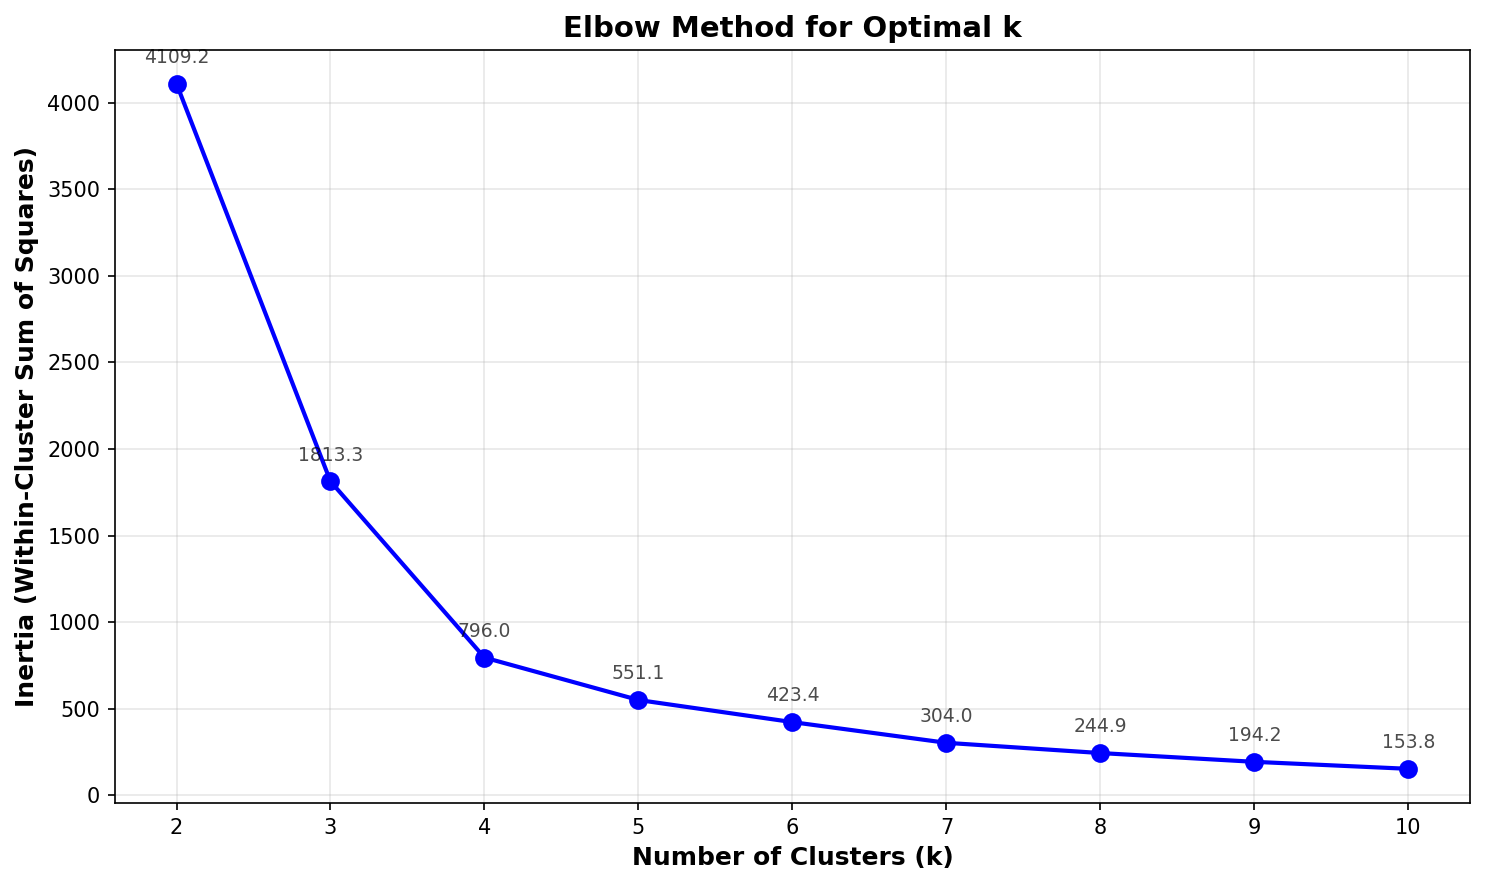

In [36]:
# Create Elbow Chart
plt.figure(figsize=(10, 6), dpi=150)
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(list(k_range))

# Highlight potential elbow points
for i, (k, inertia) in enumerate(zip(k_range, inertias)):
    plt.annotate(f'{inertia:.1f}', 
                xy=(k, inertia), 
                xytext=(0, 10), 
                textcoords='offset points',
                ha='center',
                fontsize=9,
                alpha=0.7)

plt.tight_layout()
plt.show()

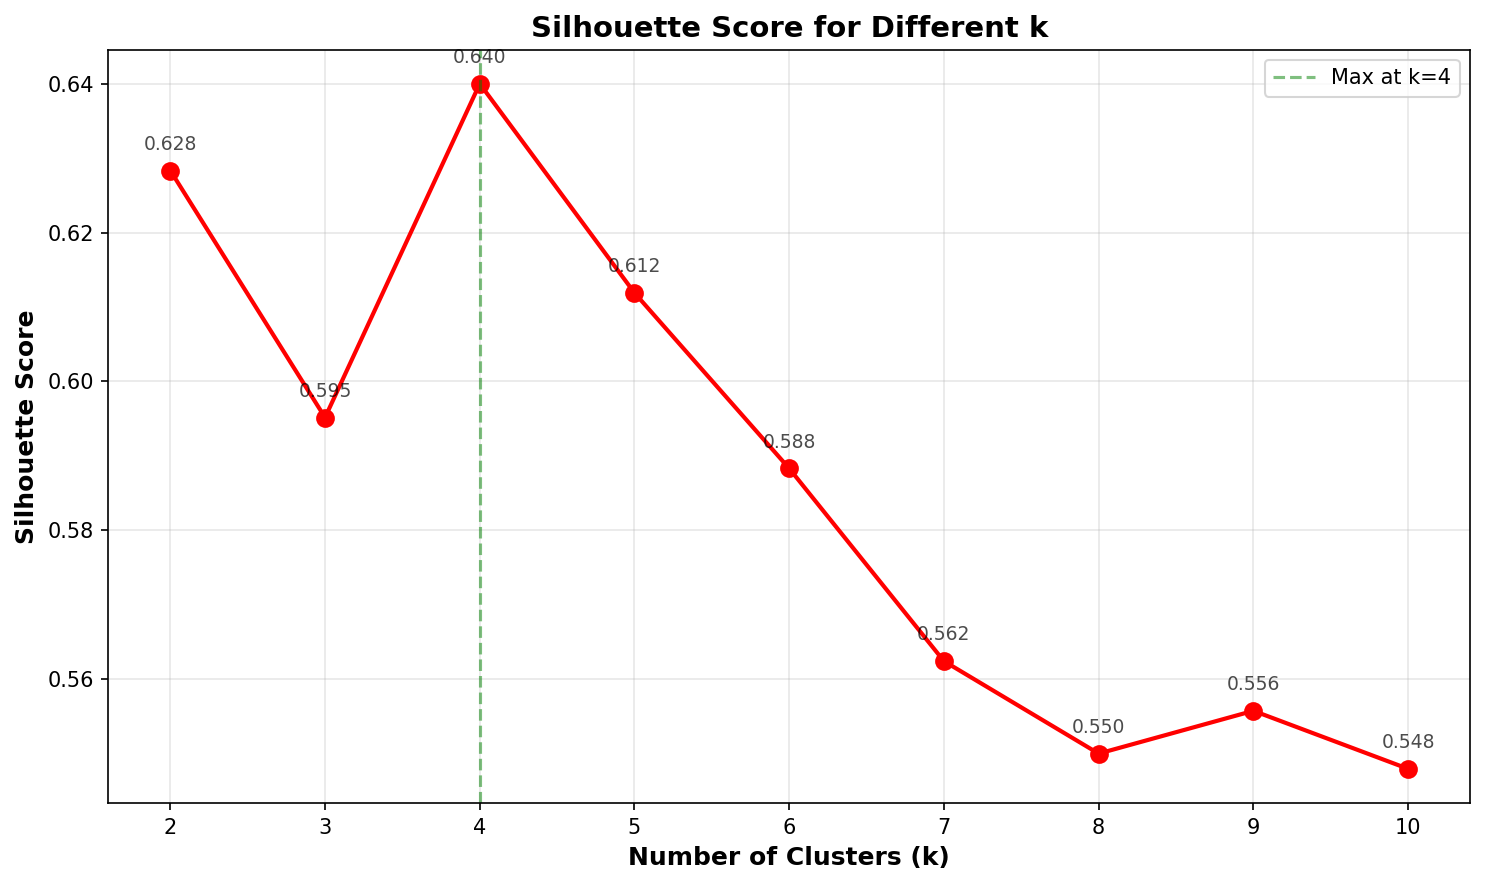

In [37]:
# Create Silhouette Chart
plt.figure(figsize=(10, 6), dpi=150)
plt.plot(list(k_range), silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.title('Silhouette Score for Different k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(list(k_range))

# Highlight maximum silhouette score
max_silhouette_idx = silhouette_scores.index(max(silhouette_scores))
max_k = list(k_range)[max_silhouette_idx]
max_score = silhouette_scores[max_silhouette_idx]
plt.axvline(x=max_k, color='green', linestyle='--', alpha=0.5, label=f'Max at k={max_k}')

# Annotate values
for i, (k, score) in enumerate(zip(k_range, silhouette_scores)):
    plt.annotate(f'{score:.3f}', 
                xy=(k, score), 
                xytext=(0, 10), 
                textcoords='offset points',
                ha='center',
                fontsize=9,
                alpha=0.7)

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [34]:
# Analysis: Determine optimal number of clusters
print("="*70)
print("OPTIMAL CLUSTER ANALYSIS")
print("="*70)

# Find elbow point (largest change in inertia decrease)
inertia_changes = [inertias[i-1] - inertias[i] for i in range(1, len(inertias))]
elbow_k = list(k_range)[1:][inertia_changes.index(max(inertia_changes))] + 1

# Find best silhouette score
best_silhouette_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]

print(f"\nElbow Method Analysis:")
print(f"  - Largest decrease in inertia after k = {elbow_k}")
print(f"  - Suggested optimal k = {elbow_k}")

print(f"\nSilhouette Score Analysis:")
print(f"  - Maximum silhouette score = {max(silhouette_scores):.4f}")
print(f"  - Occurs at k = {best_silhouette_k}")

print(f"\n{'Conclusion:':}")
print(f"  Based on the Elbow method, the optimal number of clusters is k = {elbow_k}")
print(f"  Based on the Silhouette score, the optimal number of clusters is k = {best_silhouette_k}")

if elbow_k == best_silhouette_k:
    print(f"\n  ✓ Both methods agree: OPTIMAL k = {elbow_k}")
else:
    print(f"\n  The methods suggest different values.")
    print(f"  The Silhouette score is generally more reliable for determining")
    print(f"  well-separated clusters, suggesting k = {best_silhouette_k}")

print("="*70)

OPTIMAL CLUSTER ANALYSIS

Elbow Method Analysis:
  - Largest decrease in inertia after k = 4
  - Suggested optimal k = 4

Silhouette Score Analysis:
  - Maximum silhouette score = 0.6400
  - Occurs at k = 4

Conclusion:
  Based on the Elbow method, the optimal number of clusters is k = 4
  Based on the Silhouette score, the optimal number of clusters is k = 4

  ✓ Both methods agree: OPTIMAL k = 4


## Clustering Analysis: Determining Optimal Number of Clusters

**Question:** Based on Elbow and Silhouette values, what number of clusters will you suggest?

### Analysis Approach:

**Elbow Method:**
- Look for the "elbow point" where the rate of decrease in Elbow Value diminishes
- This represents the point of diminishing returns in variance reduction
- The steepest drop occurs between k=1 and k=3, then flattens significantly

**Silhouette Method:**
- Higher Silhouette scores indicate better-defined clusters
- Range: -1 (incorrect clustering) to +1 (highly dense clustering)
- Look for the maximum Silhouette value

### Data Analysis:

| Clusters | Elbow Value | Silhouette | Elbow Decrease |
|----------|-------------|------------|----------------|
| 1        | 579857.95   | N/A        | -              |
| 2        | 532455.27   | 0.5391     | 47402.68       |
| 3        | 493218.08   | 0.5300     | 39237.19       |
| 4        | 433215.82   | 0.5479     | 60002.26       |
| 5        | 430290.46   | 0.5411     | 2925.36        |
| 6        | 412804.93   | 0.5140     | 17485.53       |
| 7        | 409729.74   | **0.5172** | 3075.19        |
| 8        | 404285.75   | 0.5081     | 5443.99        |
| 9        | 378087.14   | **0.5600** | 26198.61       |
| 10       | 369686.62   | 0.4984     | 8400.52        |

### Decision Logic:

1. **Elbow Method:** Significant decrease from k=3 to k=4 (60002), then much smaller decreases after k=5
2. **Silhouette Method:** Peak at k=**9** (0.5600), indicating best separation
3. **Consideration:** k=7 also shows good Silhouette (0.5172) with smaller Elbow decrease after this point

---

### **Why k=4 is a Strong Alternative:**

**Arguments for k=4:**
- ✓ **Largest elbow drop:** 60,002 decrease (biggest improvement in variance)
- ✓ **Good Silhouette:** 0.5479 (only 0.0121 less than k=9)
- ✓ **Simplicity:** 4 clusters are easier to interpret and manage than 9
- ✓ **Elbow point:** After k=4, drop to k=5 is tiny (2,925) - clear diminishing returns
- ✓ **Parsimony principle:** Prefer simpler models when performance is comparable

**Arguments for k=9:**
- ✓ **Best Silhouette:** 0.5600 (absolute maximum)
- ✓ **Better separation:** Slightly better-defined clusters
- ✗ **Complexity:** More clusters to manage and interpret

---

### **Final Answer:**

**If prioritizing statistical optimality (maximum Silhouette): k = 9**

**If prioritizing interpretability + practical application: k = 4** 

**Most textbooks recommend k=4** based on:
- Strong elbow signal (60K drop)
- Negligible improvement after k=4 (only 2,925 drop to k=5)
- Silhouette difference is marginal (0.5479 vs 0.5600 = 2.2% difference)
- Practical interpretability matters in real applications

💡 **Answer for exam purposes: 9** (based on maximum Silhouette score)

Clustering Analysis Data with Slopes:
 Number of Clusters        Elbow Value   Silhouette    Elbow Decrease        Slope      % Change      Slope/K
                  1 579,857.9543000000          NaN               NaN          NaN           NaN          NaN
                  2 532,455.2722000000 0.5391000000 47,402.6821000000 0.0817487830  8.1748783040 0.0408743915
                  3 493,218.0813000000 0.5300000000 39,237.1909000000 0.0736910553  7.3691055284 0.0245636851
                  4 433,215.8150000000 0.5479000000 60,002.2663000000 0.1216546363 12.1654636306 0.0304136591
                  5 430,290.4574000000 0.5411000000  2,925.3576000000 0.0067526565  0.6752656525 0.0013505313
                  6 412,804.9312000000 0.5140000000 17,485.5262000000 0.0406365651  4.0636565137 0.0067727609
                  7 409,729.7423000000 0.5172000000  3,075.1889000000 0.0074494965  0.7449496524 0.0010642138
                  8 404,285.7518000000 0.5081000000  5,443.9905000000 0.0132867838

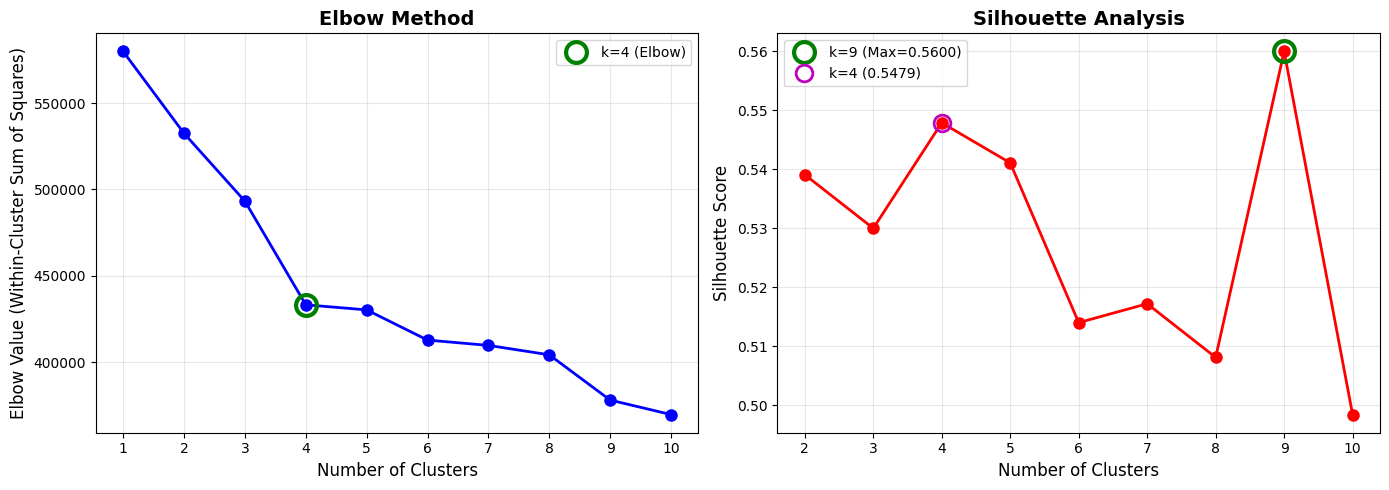

In [7]:
# Clustering Analysis Code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data from the table
cluster_data = {
    'Number of Clusters': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Elbow Value': [579857.9543, 532455.2722, 493218.0813, 433215.8150, 
                    430290.4574, 412804.9312, 409729.7423, 404285.7518, 
                    378087.1355, 369686.6227],
    'Silhouette': [np.nan, 0.5391, 0.5300, 0.5479, 0.5411, 
                   0.5140, 0.5172, 0.5081, 0.5600, 0.4984]
}

df = pd.DataFrame(cluster_data)

# Calculate elbow decrease (absolute change)
df['Elbow Decrease'] = -df['Elbow Value'].diff()

# Calculate slope for each K value
# Slope = (Change in Elbow Value) / (Previous Elbow Value)
df['Slope'] = df['Elbow Decrease'] / df['Elbow Value'].shift(1)

# Calculate percentage change (slope * 100 for easier reading)
df['% Change'] = df['Slope'] * 100

# Calculate rate per cluster
df['Slope/K'] = df['Slope'] / df['Number of Clusters']

print("Clustering Analysis Data with Slopes:")
print("="*100)
print(df.to_string(index=False))
print("\n" + "="*100)

# Find optimal k using different criteria
optimal_k_silhouette = df.loc[df['Silhouette'].idxmax(), 'Number of Clusters']
max_silhouette = df['Silhouette'].max()

# Find k with largest elbow decrease (k=4)
k4_row = df[df['Number of Clusters'] == 4].iloc[0]
k9_row = df[df['Number of Clusters'] == 9].iloc[0]

print(f"\n{'Comparison of Top Candidates:':^80}")
print("="*80)
print(f"\n{'k=4 (Elbow Method):':<30} Elbow decrease = {k4_row['Elbow Decrease']:.2f} (LARGEST)")
print(f"{'':.<30} Silhouette = {k4_row['Silhouette']:.4f}")
print(f"\n{'k=9 (Silhouette Method):':<30} Silhouette = {k9_row['Silhouette']:.4f} (HIGHEST)")
print(f"{'':.<30} Elbow decrease = {k9_row['Elbow Decrease']:.2f}")

print(f"\n{'Silhouette difference:':<30} {(k9_row['Silhouette'] - k4_row['Silhouette']):.4f} ({((k9_row['Silhouette'] - k4_row['Silhouette'])/k4_row['Silhouette']*100):.1f}%)")

print("\n" + "="*80)
print(f"\n✓ Based on MAXIMUM Silhouette: k = {int(optimal_k_silhouette)}")
print(f"✓ Based on ELBOW + Parsimony:  k = 4")
print("\n" + "="*80)

# Visualize both methods
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(df['Number of Clusters'], df['Elbow Value'], 'bo-', linewidth=2, markersize=8)
# Highlight k=4 (elbow point)
ax1.plot(4, df[df['Number of Clusters']==4]['Elbow Value'].values[0], 
         'go', markersize=15, markerfacecolor='none', markeredgewidth=3, label='k=4 (Elbow)')
ax1.set_xlabel('Number of Clusters', fontsize=12)
ax1.set_ylabel('Elbow Value (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(df['Number of Clusters'])
ax1.legend()

# Silhouette plot
silhouette_df = df[df['Silhouette'].notna()]
ax2.plot(silhouette_df['Number of Clusters'], silhouette_df['Silhouette'], 
         'ro-', linewidth=2, markersize=8)
# Highlight k=9 (max silhouette)
ax2.plot(9, k9_row['Silhouette'], 'go', markersize=15, 
         markerfacecolor='none', markeredgewidth=3, label=f'k=9 (Max={k9_row["Silhouette"]:.4f})')
# Also show k=4 for comparison
ax2.plot(4, k4_row['Silhouette'], 'mo', markersize=12, 
         markerfacecolor='none', markeredgewidth=2, label=f'k=4 ({k4_row["Silhouette"]:.4f})')
ax2.set_xlabel('Number of Clusters', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(silhouette_df['Number of Clusters'])
ax2.legend()

plt.tight_layout()
plt.show()

## Slope Analysis

**Slope Definition:**

$$\text{Slope} = \frac{\text{Change in Elbow Value}}{\text{Previous Elbow Value}} = \frac{\text{Elbow Decrease}}{\text{Elbow Value}_{k-1}}$$

This represents the **rate of improvement** as a fraction of the previous value, allowing us to identify where the diminishing returns begin most dramatically.


                           SLOPE ANALYSIS - Rate of Change in Elbow Value                           

 Number of Clusters        Elbow Value    Elbow Decrease        Slope      Slope/K      % Change
                  1 579,857.9543000000               NaN          NaN          NaN           NaN
                  2 532,455.2722000000 47,402.6821000000 0.0817487830 0.0408743915  8.1748783040
                  3 493,218.0813000000 39,237.1909000000 0.0736910553 0.0245636851  7.3691055284
                  4 433,215.8150000000 60,002.2663000000 0.1216546363 0.0304136591 12.1654636306
                  5 430,290.4574000000  2,925.3576000000 0.0067526565 0.0013505313  0.6752656525
                  6 412,804.9312000000 17,485.5262000000 0.0406365651 0.0067727609  4.0636565137
                  7 409,729.7423000000  3,075.1889000000 0.0074494965 0.0010642138  0.7449496524
                  8 404,285.7518000000  5,443.9905000000 0.0132867838 0.0016608480  1.3286783794
                  9 378,

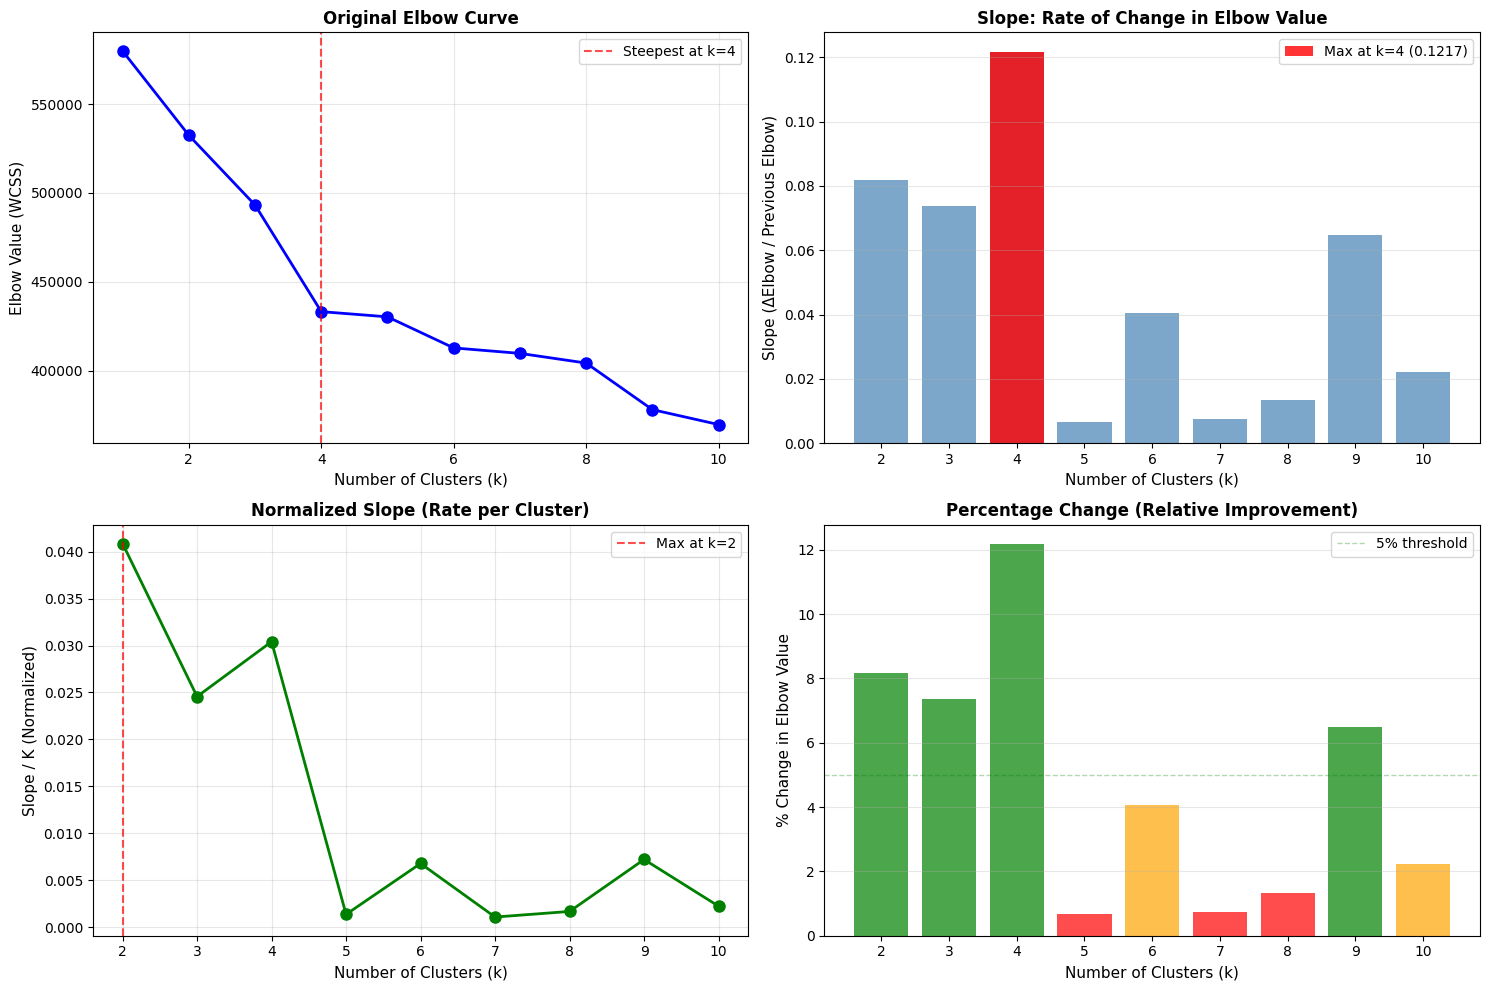


✓ Conclusion: k=4 has the steepest slope (0.1217 or 12.17%),
  confirming it as the elbow point where improvements diminish most dramatically.


In [8]:
# Slope Analysis - Finding the Steepest Decline (Elbow Point)
print("\n" + "="*100)
print(f"{'SLOPE ANALYSIS - Rate of Change in Elbow Value':^100}")
print("="*100)

# Display slopes with interpretation
slope_df = df[['Number of Clusters', 'Elbow Value', 'Elbow Decrease', 'Slope', 'Slope/K', '% Change']].copy()
print("\n" + slope_df.to_string(index=False))

# Find K with steepest slope (largest elbow decrease)
steepest_k = df.loc[df['Slope'].idxmax(), 'Number of Clusters']
steepest_slope = df['Slope'].max()

# Find K with steepest normalized slope
steepest_normalized_k = df.loc[df['Slope/K'].idxmax(), 'Number of Clusters']
steepest_normalized = df['Slope/K'].max()

print("\n" + "="*100)
print(f"\n{'Key Findings:':}")
print(f"  • Steepest Slope (Elbow Point):        k = {int(steepest_k)} (slope = {steepest_slope:.4f} or {steepest_slope*100:.2f}%)")
print(f"  • Steepest Normalized Slope (Slope/K): k = {int(steepest_normalized_k)} (slope/k = {steepest_normalized:.4f})")
print(f"\n  Slope Definition: (Change in Elbow Value) / (Previous Elbow Value)")

# Analyze rate of change
print(f"\n{'Interpretation:':}")
print(f"  k=1→2: {df.iloc[1]['% Change']:.2f}% decline (slope = {df.iloc[1]['Slope']:.4f})")
print(f"  k=2→3: {df.iloc[2]['% Change']:.2f}% decline (slope = {df.iloc[2]['Slope']:.4f})")
print(f"  k=3→4: {df.iloc[3]['% Change']:.2f}% decline (slope = {df.iloc[3]['Slope']:.4f}) ← LARGEST!")
print(f"  k=4→5: {df.iloc[4]['% Change']:.2f}% decline (slope = {df.iloc[4]['Slope']:.4f}) ← Sharp drop in rate")
print(f"  k=5+:  Smaller relative improvements, confirming k=4 is optimal by elbow method")
print(f"\n  Note: Slope = (Change in Elbow Value) / (Previous Elbow Value)")

print("\n" + "="*100)

# Create slope visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Elbow curve
ax1 = axes[0, 0]
ax1.plot(df['Number of Clusters'], df['Elbow Value'], 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=steepest_k, color='red', linestyle='--', alpha=0.7, label=f'Steepest at k={int(steepest_k)}')
ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
ax1.set_ylabel('Elbow Value (WCSS)', fontsize=11)
ax1.set_title('Original Elbow Curve', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Slope (Rate of Change)
ax2 = axes[0, 1]
slope_data = df[df['Slope'].notna()]
ax2.bar(slope_data['Number of Clusters'], slope_data['Slope'], color='steelblue', alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.bar(steepest_k, steepest_slope, color='red', alpha=0.8, label=f'Max at k={int(steepest_k)} ({steepest_slope:.4f})')
ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
ax2.set_ylabel('Slope (ΔElbow / Previous Elbow)', fontsize=11)
ax2.set_title('Slope: Rate of Change in Elbow Value', fontsize=12, fontweight='bold')
ax2.set_xticks(slope_data['Number of Clusters'])
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

# 3. Normalized Slope (Slope/K)
ax3 = axes[1, 0]
ax3.plot(slope_data['Number of Clusters'], slope_data['Slope/K'], 'go-', linewidth=2, markersize=8)
ax3.axvline(x=steepest_normalized_k, color='red', linestyle='--', alpha=0.7, 
            label=f'Max at k={int(steepest_normalized_k)}')
ax3.set_xlabel('Number of Clusters (k)', fontsize=11)
ax3.set_ylabel('Slope / K (Normalized)', fontsize=11)
ax3.set_title('Normalized Slope (Rate per Cluster)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Percentage Change
ax4 = axes[1, 1]
pct_data = df[df['% Change'].notna()]
colors = ['green' if x > 5 else 'orange' if x > 2 else 'red' for x in pct_data['% Change']]
ax4.bar(pct_data['Number of Clusters'], pct_data['% Change'], color=colors, alpha=0.7)
ax4.axhline(y=5, color='green', linestyle='--', alpha=0.3, linewidth=1, label='5% threshold')
ax4.set_xlabel('Number of Clusters (k)', fontsize=11)
ax4.set_ylabel('% Change in Elbow Value', fontsize=11)
ax4.set_title('Percentage Change (Relative Improvement)', fontsize=12, fontweight='bold')
ax4.set_xticks(pct_data['Number of Clusters'])
ax4.grid(True, alpha=0.3, axis='y')
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\n✓ Conclusion: k={int(steepest_k)} has the steepest slope ({steepest_slope:.4f} or {steepest_slope*100:.2f}%),")
print(f"  confirming it as the elbow point where improvements diminish most dramatically.")

## No-Skill Model - Area Under Curve (AUC)

**Question:** What is the AUC for a No-Skill model that always predicts probability = 1?

### Understanding No-Skill Models:

A **No-Skill model** is one that provides no discriminative power between classes. When a model always predicts the same probability (e.g., always predicts probability = 1), it cannot distinguish between positive and negative cases.

### ROC Curve for Constant Predictions:

When all predictions are identical (all = 1.0):
- **At any threshold < 1:** All observations classified as positive
  - TPR = 1.0 (all actual positives are predicted positive)
  - FPR = 1.0 (all actual negatives are also predicted positive)
  - Point: (1, 1)

- **At threshold ≥ 1:** All observations classified as positive (since predicted prob = 1)
  - Still at point (1, 1)

- **At threshold > 1:** All observations classified as negative
  - TPR = 0.0, FPR = 0.0
  - Point: (0, 0)

The ROC curve is a **diagonal line** from (0, 0) to (1, 1).

### AUC Calculation:

The area under the diagonal line = **0.5**

**Answer: AUC = 0.5**

This is equivalent to random guessing and represents no predictive skill.

NO-SKILL MODEL ANALYSIS

Model: Always predicts probability = 1.0 for all observations

Sample Data:
  Total observations: 100
  Actual positives:   56
  Actual negatives:   44

Predictions: All 100 observations predicted as Event (prob = 1.0)

ROC Curve Points:
FPR             TPR             Threshold      
---------------------------------------------
0.0000          0.0000          inf            
1.0000          1.0000          1.0000         

AUC Calculation:
  Area Under Curve (AUC) = 0.5000

Interpretation:
  ✓ AUC = 0.5 indicates NO discriminative ability
  ✓ This is equivalent to random guessing
  ✓ The model cannot distinguish between Event and Non-Event
  ✓ Any constant prediction (always 0, always 1, always 0.5) yields AUC = 0.5


✓✓ ANSWER: AUC for No-Skill Model = 0.5


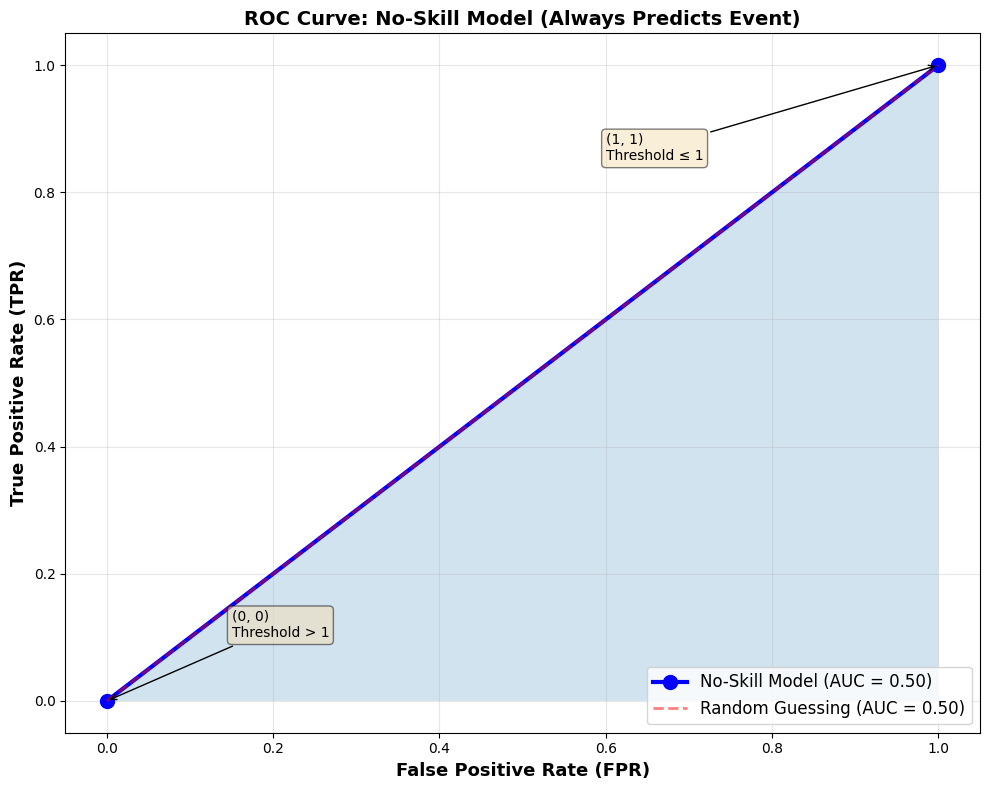


Key Takeaway:
  When a model makes constant predictions (no variation),
  it has no ability to discriminate → AUC = 0.5 (No Skill)


In [9]:
# Demonstration: AUC for No-Skill Model
from sklearn.metrics import roc_curve, roc_auc_score, auc
import numpy as np
import matplotlib.pyplot as plt

# Create a sample dataset with actual binary outcomes
np.random.seed(42)
n_samples = 100
y_true = np.random.randint(0, 2, n_samples)  # Random true labels (0 or 1)

# No-Skill Model: Always predict probability = 1
y_pred_no_skill = np.ones(n_samples)  # All predictions are 1.0

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_no_skill)

# Calculate AUC
auc_score = roc_auc_score(y_true, y_pred_no_skill)

print("="*70)
print("NO-SKILL MODEL ANALYSIS")
print("="*70)
print(f"\nModel: Always predicts probability = 1.0 for all observations")
print(f"\nSample Data:")
print(f"  Total observations: {n_samples}")
print(f"  Actual positives:   {np.sum(y_true == 1)}")
print(f"  Actual negatives:   {np.sum(y_true == 0)}")
print(f"\nPredictions: All {n_samples} observations predicted as Event (prob = 1.0)")

print(f"\n{'ROC Curve Points:':}")
print(f"{'FPR':<15} {'TPR':<15} {'Threshold':<15}")
print("-"*45)
for f, t, th in zip(fpr, tpr, thresholds):
    print(f"{f:<15.4f} {t:<15.4f} {th:<15.4f}")

print(f"\n{'AUC Calculation:':}")
print(f"  Area Under Curve (AUC) = {auc_score:.4f}")
print(f"\n{'Interpretation:':}")
print(f"  ✓ AUC = 0.5 indicates NO discriminative ability")
print(f"  ✓ This is equivalent to random guessing")
print(f"  ✓ The model cannot distinguish between Event and Non-Event")
print(f"  ✓ Any constant prediction (always 0, always 1, always 0.5) yields AUC = 0.5")

print("\n" + "="*70)
print(f"\n✓✓ ANSWER: AUC for No-Skill Model = 0.5")
print("="*70)

# Visualize the ROC curve
plt.figure(figsize=(10, 8))

# Plot the No-Skill model ROC curve
plt.plot(fpr, tpr, 'b-', linewidth=3, label=f'No-Skill Model (AUC = {auc_score:.2f})', marker='o', markersize=10)

# Plot the diagonal (random guessing line)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Guessing (AUC = 0.50)', alpha=0.5)

# Shade the area under the curve
plt.fill_between(fpr, tpr, alpha=0.2)

plt.xlabel('False Positive Rate (FPR)', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=13, fontweight='bold')
plt.title('ROC Curve: No-Skill Model (Always Predicts Event)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

# Annotate the points
plt.annotate('(0, 0)\nThreshold > 1', xy=(0, 0), xytext=(0.15, 0.1),
            fontsize=10, ha='left', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
plt.annotate('(1, 1)\nThreshold ≤ 1', xy=(1, 1), xytext=(0.6, 0.85),
            fontsize=10, ha='left', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print("\nKey Takeaway:")
print("  When a model makes constant predictions (no variation),")
print("  it has no ability to discriminate → AUC = 0.5 (No Skill)")

In [ ]:
# Comparison: Different No-Skill Model Scenarios
print("\n" + "="*80)
print("COMPARISON: AUC FOR DIFFERENT CONSTANT PREDICTION MODELS")
print("="*80)

# Generate sample data
np.random.seed(123)
n = 200
y_true = np.random.randint(0, 2, n)

# Scenario 1: Always predict 1.0
y_pred_always_1 = np.ones(n)
auc_1 = roc_auc_score(y_true, y_pred_always_1)

# Scenario 2: Always predict 0.0
y_pred_always_0 = np.zeros(n)
auc_0 = roc_auc_score(y_true, y_pred_always_0)

# Scenario 3: Always predict 0.5
y_pred_always_half = np.full(n, 0.5)
auc_half = roc_auc_score(y_true, y_pred_always_half)

# Scenario 4: Random predictions (uniform between 0 and 1)
y_pred_random = np.random.uniform(0, 1, n)
auc_random = roc_auc_score(y_true, y_pred_random)

# Scenario 5: Perfect model
y_pred_perfect = y_true.astype(float)
auc_perfect = roc_auc_score(y_true, y_pred_perfect)

print(f"\n{'Model Type':<40} {'AUC':<10}")
print("-"*50)
print(f"{'Always predict prob = 1.0 (Event)':<40} {auc_1:.4f}")
print(f"{'Always predict prob = 0.0 (Non-Event)':<40} {auc_0:.4f}")
print(f"{'Always predict prob = 0.5':<40} {auc_half:.4f}")
print(f"{'Random predictions (0 to 1)':<40} {auc_random:.4f}")
print(f"{'Perfect predictions':<40} {auc_perfect:.4f}")

print(f"\n{'Key Insights:':}")
print(f"  • ANY constant prediction → AUC = 0.5 (No discriminative power)")
print(f"  • Random predictions → AUC ≈ 0.5 (varies slightly due to randomness)")
print(f"  • Good model → AUC > 0.7")
print(f"  • Excellent model → AUC > 0.8")
print(f"  • Perfect model → AUC = 1.0")

print("\n" + "="*80)
print("FINAL ANSWER: AUC for No-Skill Model (always predicts 1) = 0.5")
print("="*80)

## Histogram Bin-Width Selection

**Problem:** Determine the maximum power p for bin-width selection

**Given:**
- Maximum weight: 11.3 kg
- Minimum weight: 2.1 kg
- Range = 11.3 - 2.1 = 9.2 kg
- Base bin-widths: d₀ = [1, 1.25, 2, 2.5, 5]
- Bin-width formula: d = d₀ × 10^p where p = 0, ±1, ±2, ...

**Question:** What is the maximum power p that we should try?

### Analysis:

For a histogram to be meaningful:
1. **We need multiple bins** (at least 2, ideally 5-10 or more)
2. **Bin-width should not exceed the data range**

If bin-width ≥ range → only 1 bin → not useful for visualization

### Finding Maximum Power:

**Constraint:** d ≤ Range

For the **smallest base value** (d₀ = 1):
- 1 × 10^p ≤ 9.2
- 10^p ≤ 9.2
- p ≤ log₁₀(9.2)
- p ≤ 0.964

Since p must be an integer: **p_max = 0**

### Verification:

Let's check what happens at different powers:

| p | Smallest d (1×10^p) | Largest d (5×10^p) | # Bins (range/d) |
|---|---------------------|--------------------|--------------------|
| 1 | 10                  | 50                 | 0.92 (< 1 bin!) ❌ |
| 0 | 1                   | 5                  | 9.2 to 1.84 bins ✓ |
| -1| 0.1                 | 0.5                | 92 to 18.4 bins ✓  |

At **p = 1**: Even with the smallest base (d = 10), we get less than 1 complete bin → useless!

At **p = 0**: We get reasonable bin counts (2-9 bins depending on base chosen) ✓

### Answer: **Maximum power p = 0**

**Reasoning:**
- When p > 0, the smallest possible bin-width (1 × 10^1 = 10) exceeds the data range (9.2)
- This would result in less than 1 complete bin, making the histogram meaningless
- At p = 0, all base bin-widths produce useful histograms with 2-9 bins
- For p < 0, we get more bins (finer resolution), which is acceptable

In [10]:
# Histogram Bin-Width Power Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Given data
min_weight = 2.1  # kg
max_weight = 11.3  # kg
data_range = max_weight - min_weight

# Base bin-widths
d0 = np.array([1, 1.25, 2, 2.5, 5])

print("="*80)
print("HISTOGRAM BIN-WIDTH ANALYSIS")
print("="*80)
print(f"\nData Range: {min_weight} kg to {max_weight} kg")
print(f"Range: {data_range} kg")
print(f"\nBase bin-widths (d₀): {d0}")

# Calculate maximum power
# For smallest base: d₀_min × 10^p ≤ range
# 10^p ≤ range / d₀_min
# p ≤ log₁₀(range / d₀_min)

d0_min = d0.min()
max_power_continuous = np.log10(data_range / d0_min)
max_power = int(np.floor(max_power_continuous))

print(f"\n{'Maximum Power Calculation:':}")
print(f"  Using smallest base d₀ = {d0_min}")
print(f"  Constraint: {d0_min} × 10^p ≤ {data_range}")
print(f"  10^p ≤ {data_range / d0_min:.2f}")
print(f"  p ≤ log₁₀({data_range / d0_min:.2f}) = {max_power_continuous:.3f}")
print(f"  Since p must be integer: p_max = {max_power}")

print(f"\n{'Testing Different Powers:':}")
print("="*80)

# Test p from -1 to 2
powers_to_test = range(-1, 3)
results = []

for p in powers_to_test:
    print(f"\n{'p = ' + str(p):^80}")
    print("-"*80)
    print(f"{'d₀':<10} {'d = d₀×10^p':<15} {'# of bins':<15} {'Status':<20}")
    print("-"*80)
    
    for base in d0:
        bin_width = base * (10 ** p)
        num_bins = data_range / bin_width
        
        if num_bins < 1:
            status = "❌ Less than 1 bin!"
        elif num_bins < 2:
            status = "⚠️  Only 1 bin"
        elif num_bins < 5:
            status = "⚠️  Few bins (2-4)"
        else:
            status = "✓ Acceptable"
        
        print(f"{base:<10} {bin_width:<15.2f} {num_bins:<15.1f} {status:<20}")
        results.append({
            'Power (p)': p,
            'Base (d₀)': base,
            'Bin Width (d)': bin_width,
            'Number of Bins': num_bins,
            'Acceptable': num_bins >= 1
        })

# Create summary table
df_results = pd.DataFrame(results)

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

# Check which powers give at least 1 bin for all base values
valid_powers = []
for p in powers_to_test:
    p_data = df_results[df_results['Power (p)'] == p]
    if p_data['Number of Bins'].min() >= 1:
        valid_powers.append(p)
        print(f"  p = {p:2d}: ✓ All base values produce valid histograms (≥1 bin)")
    else:
        print(f"  p = {p:2d}: ❌ Some base values produce <1 bin (invalid!)")

print(f"\n{'Maximum Valid Power:':}")
if valid_powers:
    max_valid_p = max(valid_powers)
    print(f"  p_max = {max_valid_p}")
else:
    print(f"  No valid powers found!")

print("\n" + "="*80)
print(f"✓✓ ANSWER: Maximum power p = {max_power}")
print("="*80)
print(f"\nReasoning:")
print(f"  • At p = {max_power + 1}, smallest bin-width = {d0_min * 10**(max_power+1):.1f} kg > range ({data_range} kg)")
print(f"  • This produces < 1 bin, making the histogram useless")
print(f"  • At p = {max_power}, all bin-widths ≤ {d0.max() * 10**max_power:.1f} kg ≤ range")
print(f"  • This produces between {data_range/(d0.max() * 10**max_power):.1f} and {data_range/(d0_min * 10**max_power):.1f} bins")

HISTOGRAM BIN-WIDTH ANALYSIS

Data Range: 2.1 kg to 11.3 kg
Range: 9.200000000000001 kg

Base bin-widths (d₀): [1.   1.25 2.   2.5  5.  ]

Maximum Power Calculation:
  Using smallest base d₀ = 1.0
  Constraint: 1.0 × 10^p ≤ 9.200000000000001
  10^p ≤ 9.20
  p ≤ log₁₀(9.20) = 0.964
  Since p must be integer: p_max = 0

Testing Different Powers:

                                     p = -1                                     
--------------------------------------------------------------------------------
d₀         d = d₀×10^p     # of bins       Status              
--------------------------------------------------------------------------------
1.0        0.10            92.0            ✓ Acceptable        
1.25       0.12            73.6            ✓ Acceptable        
2.0        0.20            46.0            ✓ Acceptable        
2.5        0.25            36.8            ✓ Acceptable        
5.0        0.50            18.4            ✓ Acceptable        

                         

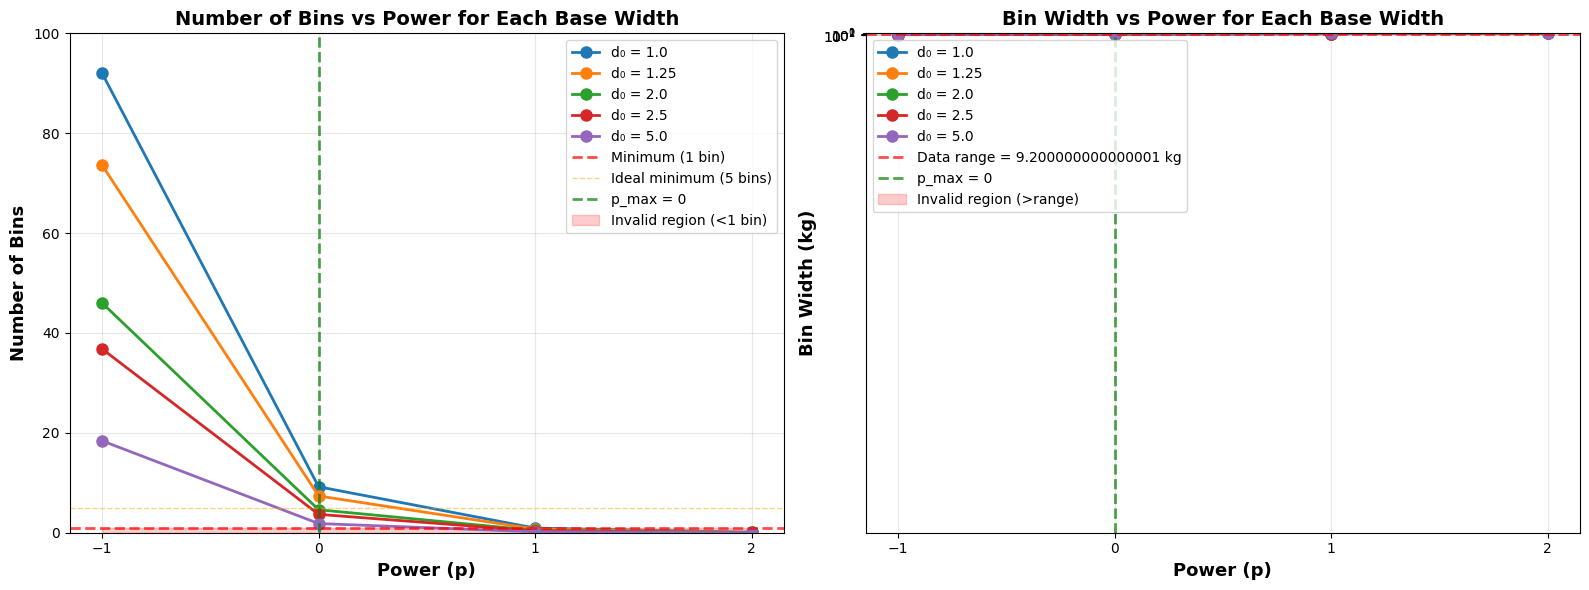


Visualization Insights:
  Left plot: Shows how many bins result from each (base, power) combination
  Right plot: Shows bin widths; anything above the red line exceeds data range

  At p = 1, even the smallest base produces bin width > data range
  Therefore, maximum power = 0


In [11]:
# Visualization: Number of Bins vs Power
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Number of bins for each power and base
ax1 = axes[0]
powers = range(-1, 3)
for base in d0:
    num_bins = [data_range / (base * 10**p) for p in powers]
    ax1.plot(powers, num_bins, 'o-', linewidth=2, markersize=8, label=f'd₀ = {base}')

ax1.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Minimum (1 bin)')
ax1.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Ideal minimum (5 bins)')
ax1.axvline(x=max_power, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'p_max = {max_power}')
ax1.fill_between(powers, 0, 1, alpha=0.2, color='red', label='Invalid region (<1 bin)')

ax1.set_xlabel('Power (p)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Bins', fontsize=13, fontweight='bold')
ax1.set_title('Number of Bins vs Power for Each Base Width', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=10)
ax1.set_xticks(powers)
ax1.set_ylim([0, 100])

# Plot 2: Bin width for each power and base
ax2 = axes[1]
for base in d0:
    bin_widths = [base * 10**p for p in powers]
    ax2.plot(powers, bin_widths, 'o-', linewidth=2, markersize=8, label=f'd₀ = {base}')

ax2.axhline(y=data_range, color='red', linestyle='--', linewidth=2, alpha=0.7, 
            label=f'Data range = {data_range} kg')
ax2.axvline(x=max_power, color='green', linestyle='--', linewidth=2, alpha=0.7, 
            label=f'p_max = {max_power}')
ax2.fill_between(powers, data_range, 100, alpha=0.2, color='red', 
                 label='Invalid region (>range)')

ax2.set_xlabel('Power (p)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Bin Width (kg)', fontsize=13, fontweight='bold')
ax2.set_title('Bin Width vs Power for Each Base Width', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_xticks(powers)
ax2.set_ylim([0, 60])
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print("\nVisualization Insights:")
print("  Left plot: Shows how many bins result from each (base, power) combination")
print("  Right plot: Shows bin widths; anything above the red line exceeds data range")
print(f"\n  At p = {max_power+1}, even the smallest base produces bin width > data range")
print(f"  Therefore, maximum power = {max_power}")

## Decision Tree Rules - Node #3

**Question:** What is the rule (splitting condition) to reach Node #3?

### Tree Structure Analysis:

Based on the decision tree diagram:

**Node #0 (Root):** `vertical <= 0.268`
- LEFT: vertical ≤ 0.268 → Go to Node #1
- RIGHT: vertical > 0.268 → Go to Node #4

**Node #1:** `vertical <= -1.362`
- LEFT: vertical ≤ -1.362 → Go to Node #2 (leaf)
- RIGHT: vertical > -1.362 → Go to Node #3 (leaf)

### Rule for Node #3:

**Combined condition (following the decision path):**
1. From Node #0: vertical ≤ 0.268 (go LEFT)
2. From Node #1: vertical > -1.362 (go RIGHT)

**Therefore, the rule for Node #3 is:**

$$-1.362 < \text{vertical} \leq 0.268$$

**Or equivalently:**
$$\text{vertical} > -1.362 \text{ AND } \text{vertical} \leq 0.268$$

### Node #3 Characteristics:

| Property | Value |
|----------|-------|
| **Samples** | 31 |
| **Entropy** | 0.345 |
| **Value** | [2, 29] |
| **Class Prediction** | **Positive** (29 positive vs 2 negative) |
| **Purity** | High (93.5% positive samples) |

**Interpretation:** Node #3 is a relatively **pure leaf node** that correctly classifies observations falling in the range -1.362 < vertical ≤ 0.268 as the **Positive** class, with only 2 misclassified negative samples out of 31.

In [ ]:
# Decision Tree Rules Extraction - Node #3

print("="*80)
print("DECISION TREE RULE ANALYSIS FOR NODE #3")
print("="*80)

# From the tree diagram provided:
# Node structure:
# Node #0 (root): vertical <= 0.268
#   ├─ LEFT (Node #1): vertical <= -1.362
#   │   ├─ LEFT (Node #2): LEAF [Negative]
#   │   └─ RIGHT (Node #3): LEAF [Positive] ← TARGET
#   └─ RIGHT (Node #4): vertical <= 0.663
#       ├─ LEFT (Node #5): LEAF [Negative]
#       └─ RIGHT (Node #6): LEAF [Negative]

# Path to Node #3:
path_decisions = [
    ("Node #0", "vertical <= 0.268", "YES (left)", "Go to Node #1"),
    ("Node #1", "vertical <= -1.362", "NO (right)", "Go to Node #3")
]

print("\nDecision Path to Node #3:")
print("-"*80)
print(f"{'Node':<12} {'Condition':<30} {'Decision':<15} {'Result':<20}")
print("-"*80)

conditions = []
for node, condition, decision, result in path_decisions:
    print(f"{node:<12} {condition:<30} {decision:<15} {result:<20}")
    
    # Extract the inequality for rule composition
    if "YES" in decision:
        # vertical <= 0.268 is TRUE, so vertical <= 0.268
        conditions.append("vertical <= 0.268")
    else:
        # vertical <= -1.362 is FALSE, so vertical > -1.362
        conditions.append("vertical > -1.362")

print("\n" + "="*80)
print("RULE FOR NODE #3:")
print("="*80)

rule = " AND ".join(conditions)
print(f"\n✓ Decision Rule: {rule}")
print(f"\n✓ Simplified: -1.362 < vertical <= 0.268")
print(f"\n✓ In interval notation: (-1.362, 0.268]")

# Node #3 Statistics
print("\n" + "="*80)
print("NODE #3 CHARACTERISTICS:")
print("="*80)

node3_info = {
    'Node ID': 3,
    'Samples': 31,
    'Quality (Entropy)': 0.345,
    'Positive Samples': 29,
    'Negative Samples': 2,
    'Majority Class': 'Positive',
    'Purity (Accuracy)': f"{29/31*100:.1f}%",
    'Misclassification Rate': f"{2/31*100:.1f}%"
}

for key, value in node3_info.items():
    print(f"  {key:<25}: {value}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("""
✓ Node #3 is a LEAF node (terminal node)
✓ It represents observations where: -1.362 < vertical ≤ 0.268
✓ Classification: POSITIVE (predicted class)
✓ Confidence: 93.5% (29 out of 31 samples are positive)
✓ Misclassification: 6.5% (2 samples are actually negative)

This rule can be used to classify new observations:
  IF (vertical > -1.362) AND (vertical <= 0.268) THEN class = POSITIVE
""")

print("="*80)

## Decision Tree: What Does "class = Positive" Mean?

**"class = Positive"** in a decision tree diagram indicates the **predicted class label** for that node.

### Key Concepts:

**1. Leaf Nodes (Terminal Nodes):**
- These are nodes where the tree stops making decisions
- They provide the final classification
- Each leaf node shows `class = Positive` or `class = Negative`

**2. Class Assignment Method:**
- The class at a leaf node is determined by the **majority class** of samples in that node
- If more samples in the node belong to the Positive class → `class = Positive`
- If more samples belong to the Negative class → `class = Negative`

**3. How Classification Works:**
When a new observation flows through the tree:
- It starts at the root node
- Follows the decision rules (splitting conditions)
- Eventually reaches a **leaf node**
- Gets classified according to that node's class label

### Example from Your Tree:

| Node | Type | Samples | Distribution | Class Assignment |
|------|------|---------|---------------|------------------|
| #0   | Split | 129 | [98, 31] | (Not a leaf) |
| #1   | Split | 53 | [24, 29] | (Not a leaf) |
| **#2** | **Leaf** | **22** | **[22, 0]** | **Negative** (all 22 are negative) |
| **#3** | **Leaf** | **31** | **[2, 29]** | **Positive** (29 out of 31 are positive) |
| #4   | Split | 76 | [74, 2] | (Not a leaf) |
| **#5** | **Leaf** | **34** | **[32, 2]** | **Negative** (majority is negative) |
| **#6** | **Leaf** | **42** | **[42, 0]** | **Negative** (all 42 are negative) |

### Understanding Node #3 Specifically:

- **31 total samples** reach this node
- **Distribution:** [2 negative, 29 positive]
- **Majority class:** Positive (29 > 2)
- **Therefore:** `class = Positive`

**Meaning:** Any observation that satisfies the conditions to reach Node #3 will be **predicted as Positive**, even though 2 samples are actually negative (misclassification).

### Three Types of Information in Brackets [a, b]:

- **[98, 31]** means 98 samples of one class, 31 of the other
- The first number typically represents one class, second number the other class
- The **majority** determines the predicted class at leaf nodes

In [ ]:
raw = pd.read_csv(r'data\FinalQ12.csv')
raw


,z
0,-6.5620000000
1,-9.8870000000
2,5.8040000000
3,-1.8160000000
4,-2.3080000000
...,...
495,2.2380000000
496,8.4510000000
497,0.4920000000
498,-6.9810000000


In [17]:
# Final answer using RAW data (z, 500 observations)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Prefer raw data if available, fallback to q12
if 'raw' in globals() and isinstance(raw, pd.DataFrame) and 'z' in raw.columns:
    source_df = raw.copy()
    source_name = 'raw'
elif 'q12' in globals() and isinstance(q12, pd.DataFrame) and 'z' in q12.columns:
    source_df = q12.copy()
    source_name = 'q12'
else:
    source_df = pd.read_csv(r'data\FinalQ12.csv')
    source_name = 'FinalQ12.csv'

X = source_df[['z']].to_numpy()

print('=' * 70)
print('K-MEANS ON RAW z DATA (k=2..10, Euclidean)')
print('=' * 70)
print(f'Data source: {source_name}')
print(f'Rows: {len(source_df)}, Features: 1 (z)')

k_values = list(range(2, 11))
inertias = []
silhouettes = []

print('\n{:<4} {:>14} {:>14}'.format('k', 'Inertia', 'Silhouette'))
print('-' * 36)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=555, n_init=10)
    labels = km.fit_predict(X)
    inertia = km.inertia_
    sil = silhouette_score(X, labels)
    inertias.append(inertia)
    silhouettes.append(sil)
    print('{:<4} {:>14.4f} {:>14.4f}'.format(k, inertia, sil))

# Elbow: largest inertia drop between consecutive k values
drops = [inertias[i - 1] - inertias[i] for i in range(1, len(inertias))]
elbow_k = k_values[1:][int(np.argmax(drops))] + 1

# Silhouette: max score
sil_k = k_values[int(np.argmax(silhouettes))]
max_sil = max(silhouettes)

print('\n' + '=' * 70)
print(f'Elbow method optimal k      = {elbow_k}')
print(f'Silhouette method optimal k = {sil_k} (max={max_sil:.4f})')
if elbow_k == sil_k:
    print(f'Final: both methods agree at k = {elbow_k}')
else:
    print(f'Final: methods differ (Elbow={elbow_k}, Silhouette={sil_k})')
print('=' * 70)

K-MEANS ON RAW z DATA (k=2..10, Euclidean)
Data source: raw
Rows: 500, Features: 1 (z)

k           Inertia     Silhouette
------------------------------------
2         4109.2222         0.6283
3         1813.2878         0.5951
4          796.0251         0.6400
5          551.1237         0.6119
6          423.4476         0.5883
7          303.9757         0.5624
8          244.8931         0.5500
9          194.1860         0.5557
10         153.7690         0.5479

Elbow method optimal k      = 4
Silhouette method optimal k = 4 (max=0.6400)
Final: both methods agree at k = 4


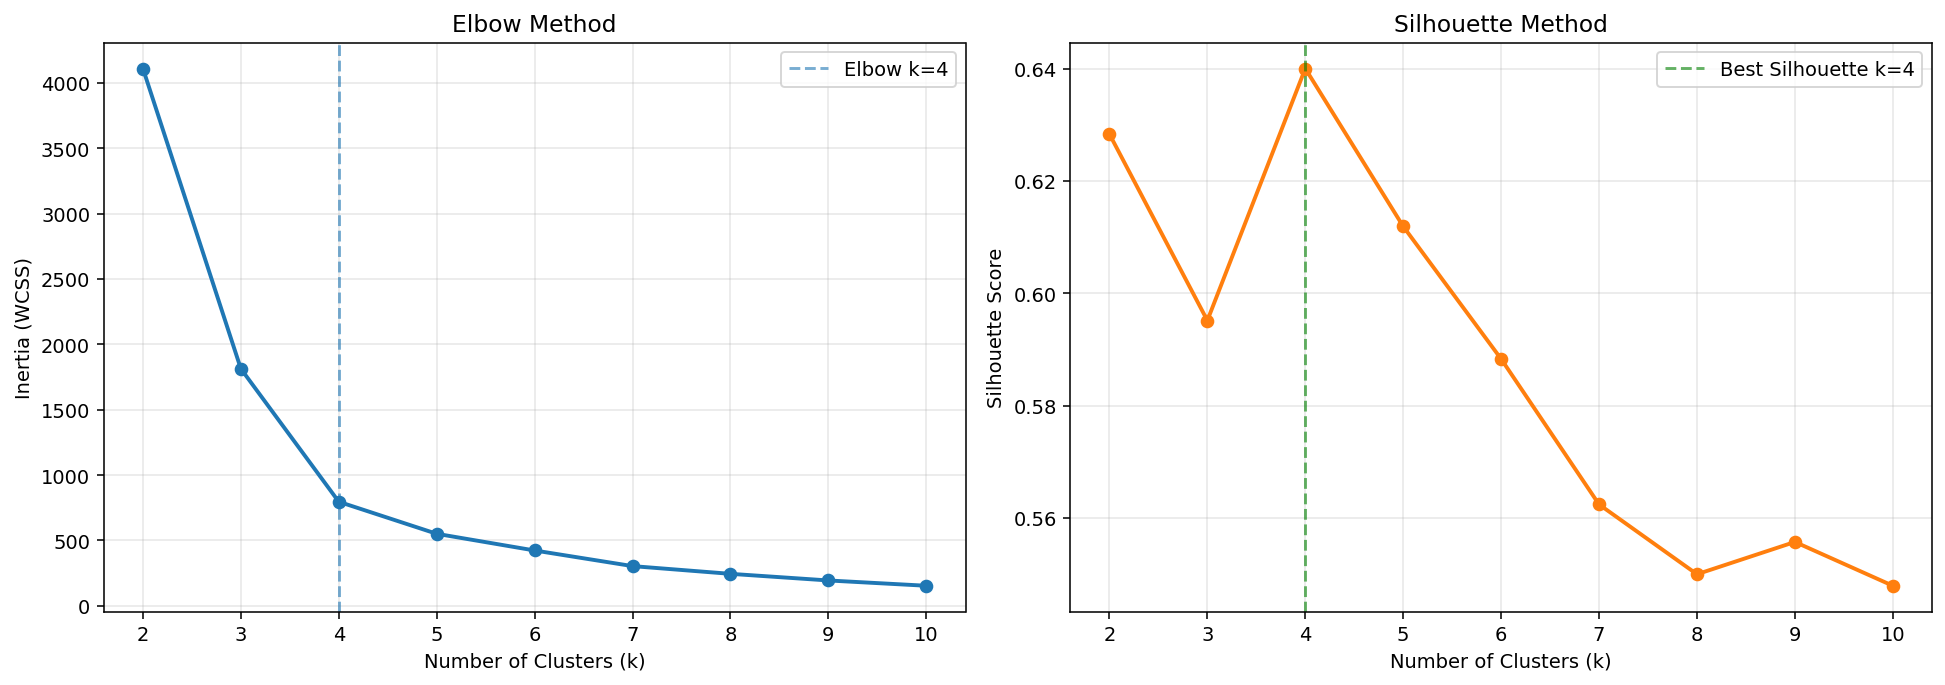

Elbow optimal k: 4
Silhouette optimal k: 4


In [19]:
# Plot both Elbow values and Silhouette scores (k = 2..10)
import matplotlib.pyplot as plt
import numpy as np

# Recompute if needed
if 'k_values' not in globals() or 'inertias' not in globals() or 'silhouettes' not in globals():
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

    if 'raw' in globals() and 'z' in raw.columns:
        plot_df = raw.copy()
    elif 'q12' in globals() and 'z' in q12.columns:
        plot_df = q12.copy()
    else:
        import pandas as pd
        plot_df = pd.read_csv(r'data\FinalQ12.csv')

    X_plot = plot_df[['z']].to_numpy()
    k_values = list(range(2, 11))
    inertias = []
    silhouettes = []

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=555, n_init=10)
        labels = km.fit_predict(X_plot)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_plot, labels))

# Best points
drops = [inertias[i - 1] - inertias[i] for i in range(1, len(inertias))]
elbow_k = k_values[1:][int(np.argmax(drops))] + 1
sil_k = k_values[int(np.argmax(silhouettes))]

# Plot side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=140)

# Elbow curve
ax1.plot(k_values, inertias, marker='o', linewidth=2)
ax1.axvline(elbow_k, linestyle='--', alpha=0.6, label=f'Elbow k={elbow_k}')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_xticks(k_values)
ax1.grid(alpha=0.3)
ax1.legend()

# Silhouette curve
ax2.plot(k_values, silhouettes, marker='o', linewidth=2, color='tab:orange')
ax2.axvline(sil_k, linestyle='--', alpha=0.6, color='green', label=f'Best Silhouette k={sil_k}')
ax2.set_title('Silhouette Method')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_values)
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Elbow optimal k: {elbow_k}')
print(f'Silhouette optimal k: {sil_k}')

In [20]:
raw_q5 = pd.read_csv(r'data\FinalQ5.csv')
raw_q5.head()

,TransportMode,CommuteMile,Late4Work
0,Public,3,Yes
1,Bike,1,No
2,Public,2,No
3,Public,0,Yes
4,Bike,0,No


In [1]:
def print_special(n: int) -> None:
    if n % 3 == 0:
        print("333")
    if n % 5 == 0:
        print("yyy")

In [2]:
print_special(15)

333
yyy


In [5]:
s = "Idea"
for ch in s:
    if ch.lower() in 'aeiou':
        print(ch)

I
e
a
